# PCA (Principal component analysis)

Linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space

- PCA transforms the data into a new dimensionap space, where each dimension is orthogonal to each other
- Principal Components, which are a linear combination of the original datasets features, are sorted according to highest to lowest variance
- The Assumption is, that the 

In [276]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
# %config InlineBackend.figure_format = 'svg'

In [277]:
breast_cancer = datasets.load_breast_cancer()
x = breast_cancer.data 

# Exercise 2.1

Ex: Following the procedure in chapter 2.1 of the lecture notes, write a Python function that implements PCA. The input to this function shoudl be the data itself and a variable specifying the number of components we want to keep. The function 'np.linalg.eig' might be useful

In [278]:
def PCA(data,components):
    # 1) Centering the data
    # Compute mean of dataset
    value = 0
    for i in range(data.shape[0]):
        value = value + data[i,:]
        i += 1
    mean = 1/len(data)*value
    
# Creating Empy array of dimension 569x30
    X = np.ones((data.shape[0], data.shape[1]), dtype = float)
    for i in range(data.shape[0]):
        X[i] = data[i,:] - mean
        i += 1

# Forming Covariance Matrix 
    C = np.ones((data.shape[1], data.shape[1]), dtype = float)
    C = np.dot(X.transpose(), X)
    
# Diagonalize the Matrix
    eig_val, eig_vec = np.linalg.eig(C)
    
# Sorting the eigenvalues from largest to smallest
    idx = eig_val.argsort()[::-1]
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:,idx]
    
# Picking the l largest eigenvalues
    if components > data.shape[1]:
        print("You need to choose a smaller amount of component dimensionality")
    else:
        eig_val_chosen = eig_val[:components]
        # Constructing the n times l matrix W
        eig_vec_chosen = eig_vec[:,:components]

# Dimensional reduction, Transform the data matriX
    X_new = np.dot(X, eig_vec_chosen)
    
# Plotting the Data (for the 2 component PCA)
    if components == 2:
        x = X_new[:,0]
        y = X_new[:,1]
        plt.style.use('seaborn')
        fig = plt.figure(figsize = (10,10))
        plt.ax = fig.add_subplot(1,1,1) 
        plt.ax.set_xlabel('Principal Component 1', fontsize = 15)
        plt.ax.set_ylabel('Principal Component 2', fontsize = 15)
        plt.ax.set_title('2 component PCA', fontsize = 20)
        plt.scatter(x,y, s = 10)
        plt.legend()
        plt.show()
    if components == 3:
        x = X_new[:,0]
        y = X_new[:,1]
        z = X_new[:,2]
        fig = plt.figure(figsize = (10,10))
        plt.ax = fig.add_subplot(1,1,1, projection = '3d') 
        plt.ax.set_xlabel('Principal Component 1', fontsize = 15)
        plt.ax.set_ylabel('Principal Component 2', fontsize = 15)
        plt.ax.set_zlabel('Principal Component 3', fontsize = 15)
        plt.ax.set_title('2 component PCA', fontsize = 20)
        plt.scatter(x,y,z)
        plt.show()

### 2 Component PCA Plotted

No handles with labels found to put in legend.


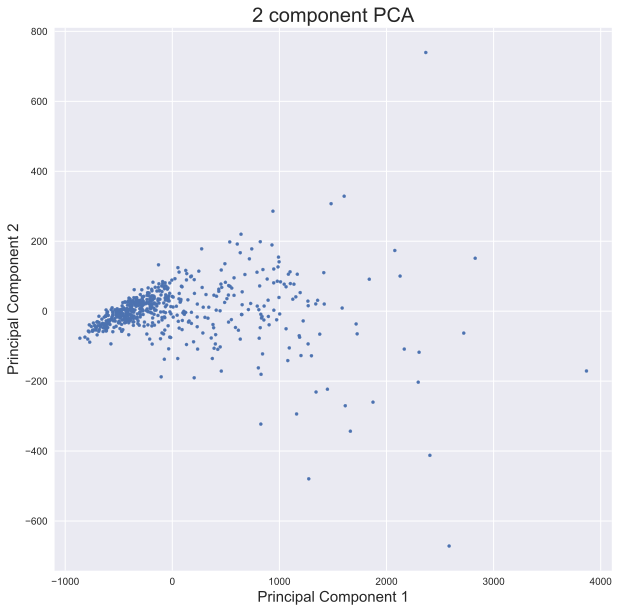

In [279]:
PCA(x,2)

# Exercise 2.2

Ex: Most machine learning algorithms are already implement in highly efficient packages. Check your implementation by using Scikit-Learn function for PCA, which can be imported by calling from 

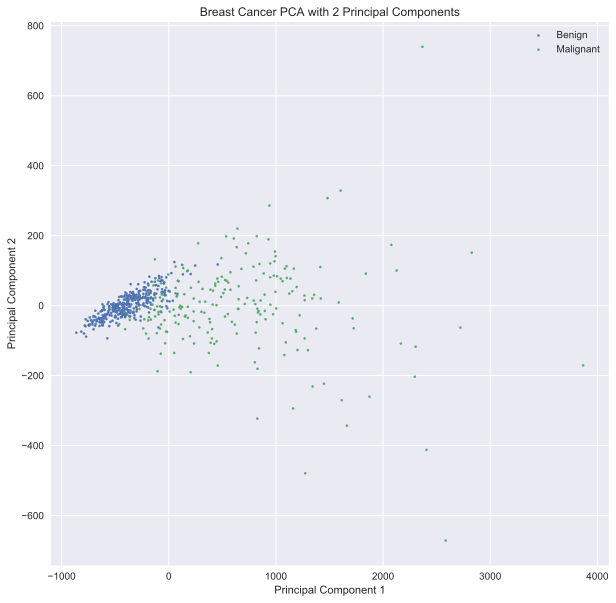

In [282]:
# Implementing the Scikit functions for the PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca.fit(breast_cancer.data)
bc_target = breast_cancer.target
# bc_pve = pve(bc_data)
# x = pca.transform(x)
red_bc_data = pca.transform(breast_cancer.data)

malignant_w1 = red_bc_data[:,0][bc_target == 0]
malignant_w2 = red_bc_data[:,1][bc_target == 0]
benign_w1 = red_bc_data[:, 0][bc_target == 1]
benign_w2 = red_bc_data[:, 1][bc_target == 1]

# Plotting
%config InlineBackend.figure_format = 'svg'
plt.style.use('seaborn')
# fig1 = plt.figure(figsize = (10,10))
fig = plt.figure(figsize = (10,10))
plt.ax = fig.add_subplot(1,1,1) 
plt.ax.set_xlabel('Principal Component 1')
plt.ax.set_ylabel('Principal Component 2')
plt.ax.set_title("Breast Cancer PCA with 2 Principal Components")
plt.scatter(bening_w1, benign_w2, s=5, label= "Benign")
plt.scatter(malignant_w1, malignant_w2, s=5, label = "Malignant")
# plt.scatter(x[:,0], x[:,1], s = 10)

plt.legend()
plt.show()

### Histogram for Horizontal Principal Component 1

/Users/fabianjaeger/opt/anaconda3/envs/ml/lib/python3.7/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


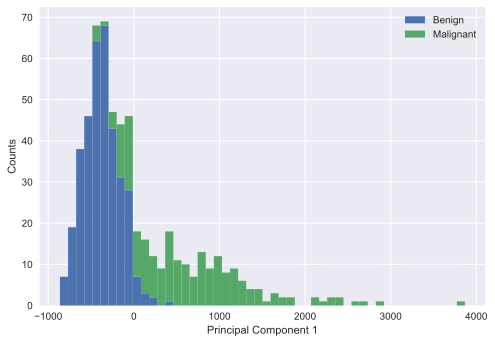

In [283]:
plt.hist([benign_w1, malignant_w1], bins = 50, label = ["Benign", "Malignant"], histtype = "barstacked")
plt.legend()
plt.xlabel("Principal Component 1")
plt.ylabel("Counts")
plt.show()

# Exercise 2.3

Ex: Can you think of a systematic way of selecting the number of components we want to keep after PCA? One way is to calculate the proportion of variance explained (PVE), defined as the variance of a principle component divided by the total variance. Equivalently, this can be calculated as
$$ PVE_i = \frac{\Lambda_i}{\sum_j \Lambda_j} $$
where $\Lambda_i$ is the eigenvalue of the i-th principle component. Calculate this quantitiy and plot it for all features. This is called scree plot. An ideal curve should be steep, then bends at an elbow - this is your cutting-off point - and after that flattens out.

In [284]:
def PVE(Data):
    value = 0
    for i in range(Data.shape[0]):
        value = value + Data[i,:]
        i += 1
    mean = 1/len(Data)*value
    
# Creating Empy array of dimension 569x30
    X = np.ones((Data.shape[0], Data.shape[1]), dtype = float)
    print(X.shape)
    for i in range(Data.shape[0]):
        X[i] = Data[i,:] - mean
        i += 1

# Forming Covariance Matrix 
    C = np.ones((Data.shape[1], Data.shape[1]), dtype = float)
    C = np.dot(X.transpose(), X)
    
# Diagonalize the Matrix
    eig_val, eig_vec = np.linalg.eig(C)
    
# Sorting the eigenvalues from largest to smallest
    idx = eig_val.argsort()[::-1]
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:,idx]
    
    PVE = np.ones(Data.shape[1], dtype = float)
    for i in range(Data.shape[1]):
        PVE[i]= eig_val[i]/(sum(eig_val))
    
    y = np.linspace(0,30,30)
    
    fig = plt.figure(figsize = (10,10))
    plt.ax = fig.add_subplot(1,1,1) 
    plt.ax.set_xlabel('Features')
    plt.ax.set_ylabel('Proportion of Variance Explained')
    plt.ax.set_title("Scree Plot")
    plt.scatter(y, PVE, s=15)
    plt.show()

(569, 30)


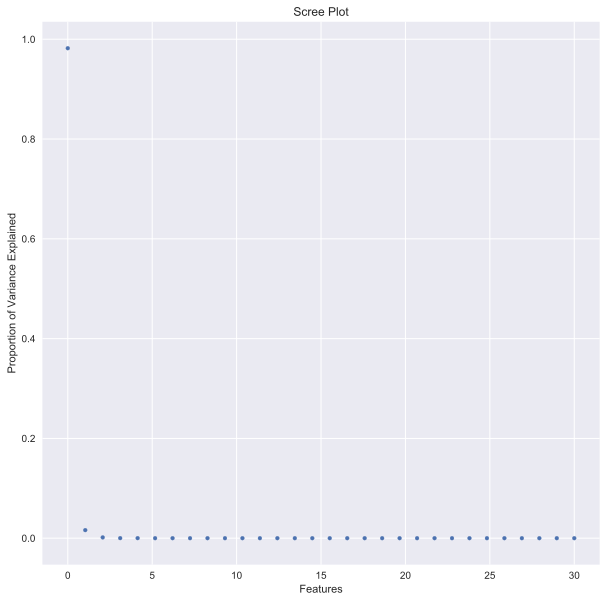

In [285]:
PVE(breast_cancer.data)

## Exercise 2.4
Now that you got to know how PCA works and where it can be of benefit, what could be reasons not to use it?

- Relies on linear assumptions

- PCA should be mainly for variables which are strongly correlated.

- Largest variance does not necessarily mean its the most relevant for finding a way to differentiate between the two classes (benign, malignant)